Mean treatment effect pre-2022: 0.019023240354867695
Mean treatment effect post-2022: 0.017988066624410416


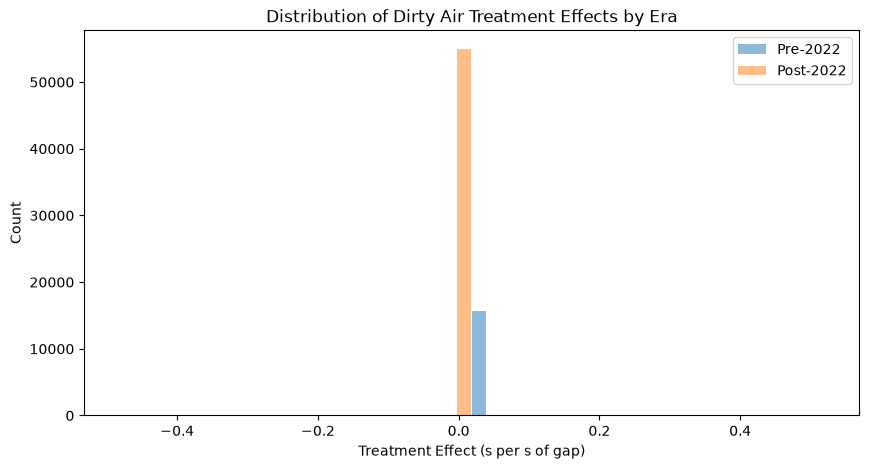

In [1]:
import pandas as pd
import numpy as np
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

df = pd.read_csv('physics_adjusted_dataset.csv')
df = df.dropna(subset=['CorrectedLapTime', 'GapToCarAhead', 'Compound', 'Circuit', 'Season', 'TyreLife', 'LapNumber'])

df['IsPost2022'] = (df['Season'] >= 2022).astype(int)

# same both era circuit filter as the OLS specification, for consistency
circuit_era_counts = df.groupby('Circuit')['IsPost2022'].nunique()
both_era_circuits = circuit_era_counts[circuit_era_counts == 2].index
df = df[df['Circuit'].isin(both_era_circuits)]

le_circuit = LabelEncoder()
le_compound = LabelEncoder()
df['Circuit_enc'] = le_circuit.fit_transform(df['Circuit'])
df['Compound_enc'] = le_compound.fit_transform(df['Compound'])

T = df['GapToCarAhead'].values          # treatment: following distance
Y = df['CorrectedLapTime'].values       # outcome
X = df[['IsPost2022']].values           # heterogeneity variable: pre vs post 2022
W = df[['Circuit_enc', 'Compound_enc', 'TyreLife', 'LapNumber']].values  # controls

model = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, n_jobs=-1),
    model_t=RandomForestRegressor(n_estimators=100, n_jobs=-1),
    n_estimators=200,
    random_state=42
)
model.fit(Y, T, X=X, W=W)

effects = model.effect(X)
df['TreatmentEffect'] = effects

print("Mean treatment effect pre-2022:", df[df['IsPost2022']==0]['TreatmentEffect'].mean())
print("Mean treatment effect post-2022:", df[df['IsPost2022']==1]['TreatmentEffect'].mean())

plt.figure(figsize=(10, 5))
plt.hist(df[df['IsPost2022']==0]['TreatmentEffect'], bins=50, alpha=0.5, label='Pre-2022')
plt.hist(df[df['IsPost2022']==1]['TreatmentEffect'], bins=50, alpha=0.5, label='Post-2022')
plt.xlabel('Treatment Effect (s per s of gap)')
plt.ylabel('Count')
plt.title('Distribution of Dirty Air Treatment Effects by Era')
plt.legend()
plt.show()